# Image Classification with CNN (CIFAR-10)


Bu proje, CIFAR-10 veri kümesindeki 10 farklı görüntü sınıfını (uçak, araba, kuş, kedi, geyik, köpek, kurbağa, at, gemi, kamyon) Convolutional Neural Network (CNN) kullanarak sınıflandırmayı amaçlamaktadır.  

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Reshape, InputLayer, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
y_train.shape

(50000, 1)

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [8]:
def showImage(x, y, index):
  plt.figure(figsize=(15,3))
  plt.imshow(x[index])
  plt.xlabel(class_names[y[index][0]])

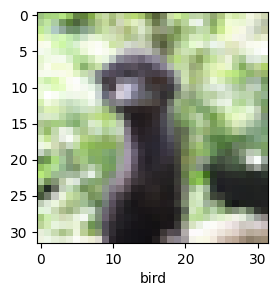

In [9]:
showImage(x_train, y_train, 55)

In [12]:
model = Sequential()

In [13]:
# Giriş katmanı
model.add(InputLayer(shape=(32, 32, 3)))

In [14]:
# İlk konvolüsyon bloğu
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

In [15]:
# İkinci konvolüsyon bloğu
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

In [16]:
# Üçüncü konvolüsyon bloğu
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))

In [17]:
# Düzleştirme
model.add(Flatten())

In [18]:
# Tam bağlantılı katmanlar
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10))  # 10 sınıf

In [19]:
# 5. Model Egitme
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [20]:
history = model.fit(x_train, y_train, validation_split=0.1, epochs=10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 140s 96ms/step - accuracy: 0.3686 - loss: 1.7331 - val_accuracy: 0.5014 - val_loss: 1.3110
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 137s 92ms/step - accuracy: 0.5603 - loss: 1.2050 - val_accuracy: 0.5232 - val_loss: 1.5394
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 128s 91ms/step - accuracy: 0.6403 - loss: 1.0076 - val_accuracy: 0.6602 - val_loss: 0.9402
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 127s 90ms/step - accuracy: 0.6887 - loss: 0.8765 - val_accuracy: 0.6994 - val_loss: 0.8638
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 128s 91ms/step - accuracy: 0.7266 - loss: 0.7808 - val_accuracy: 0.7240 - val_loss: 0.7985
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.7573 - loss: 0.6870 - val_accuracy: 0.6892 - val_loss: 0.9917
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 131s 93ms/step - accuracy: 0.7781 - loss: 0.6261 - val_accuracy: 0.7200 - val_loss: 0.8306
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 129s 92ms/step - accuracy: 

In [22]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest doğruluğu: {test_acc:.3f}")

313/313 - 7s - 23ms/step - accuracy: 0.6874 - loss: 0.9979

Test doğruluğu: 0.687


In [28]:
index = 34
image = x_test[index].reshape(1, 32, 32, 3)

In [29]:
prediction = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [30]:
pred_label = class_names[np.argmax(prediction)]
true_label = class_names[int(y_test[index][0])]

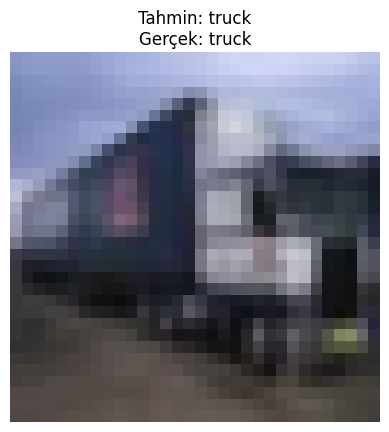

In [31]:
plt.imshow(x_test[index])
plt.title(f"Tahmin: {pred_label}\nGerçek: {true_label}")
plt.axis('off')
plt.show()

Model, TensorFlow ve Keras ile oluşturulmuş olup veriler normalize edilerek eğitilmiştir. Model, 10 epoch sonunda val_accuracy: 0.75 elde etti. Eğitim doğruluğu yüksek, doğrulama doğruluğu biraz daha düşük olup hafif overfitting gözlenmiştir. Veri artırma (data augmentation) ve dropout gibi yöntemlerle doğruluk daha da artırılabilir.